In [70]:
import jax
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import immrax as irx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cvxpy as cp
import scipy
from immutabledict import immutabledict
from reach import *
from functools import partial
import control
from GPR import *
from TVGPR import *

# Some configurations
jax.config.update("jax_enable_x64", True)

# We wrap the jax.jit function t/o set the backend to cpu by default for convenience.
device = 'cpu'
def jit (*args, **kwargs):
    kwargs.setdefault('backend', device)
    return jax.jit(*args, **kwargs)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14
})

np.random.seed(0)

In [71]:
# system dynamics and initial conditions

class PlanarMultirotor (irx.System) :
    def __init__ (self) :
        self.xlen = 5
        self.evolution = 'continuous'

    def f(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        u1, u2 = u.ravel()
        w1 = w[0]
        g = 9.81

        return jnp.array([
            vx,
            vy,
            -1*u1*jnp.sin(theta) + w1,
            u1*jnp.cos(theta) - g,
            u2
        ])

sys = PlanarMultirotor()

# initial conditions
x0 = jnp.array([1., 0.5, 0., 0., 0.1])
u0 = jnp.array([11.0, 0.])

w0 = jnp.array([0.0])

# x0_buf = 0.05 * jnp.array([1.0, 1.0, 1.0, 1.0, 1.0])
x0_buf = jnp.array([0.01, 0.01, 0.01, 0.01, 0.01])*0.1
ix0 = irx.icentpert(x0, x0_buf)
print(ix0)

GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 1.]]))

[[( 0.999, 1.001e+00)]
 [( 0.499, 5.010e-01)]
 [(-0.001, 1.000e-03)]
 [(-0.001, 1.000e-03)]
 [( 0.099, 1.010e-01)]]


In [72]:
def disturbance (t, x) :
    return GP.mean(jnp.array([x[1]])).reshape(-1)
    # return GP.mean(x[(0,),])
print(ix0[(0,),])
print(x0[0])

def tr (x) :
    # return x[(0,),]
    return jnp.array([x[0]])

# print(tr(ix0))
print(irx.natif(tr)(ix0))
print(disturbance(0.0, x0))

[[(0.999, 1.001)]]
1.0
[[(0.999, 1.001)]]
[1.01703524]


In [73]:
# determinant helper function, can't use np.linalg.det because it uses a primitive not in immrax
def getDet(mat, n=5):
  
    # Base case: if the matrix is 1x1
    if n == 1:
        return mat[0][0]
    
    # Base case for 2x2 matrix
    if n == 2:
        return mat[0][0] * mat[1][1] - \
               mat[0][1] * mat[1][0]
    
    # Recursive case for larger matrices
    res = 0
    for col in range(n):
      
        # Create a submatrix by removing the first 
        # row and the current column
        sub = [[0] * (n - 1) for _ in range(n - 1)]
        for i in range(1, n):
            subcol = 0
            for j in range(n):
              
                # Skip the current column
                if j == col:
                    continue
                
                # Fill the submatrix
                sub[i - 1][subcol] = mat[i][j]
                subcol += 1
        
        # Cofactor expansion
        sign = 1 if col % 2 == 0 else -1
        res += sign * mat[0][col] * getDet(sub, n - 1)
    
    return res

In [74]:
# Get initial P, K from LQR

# linearize system around x0, u0
A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, w0))(x0), jax.jacfwd(lambda u: sys.f(0, x0, u, w0))(u0)
# print(A)
# print(B)

# weight matrices
Q = jnp.array([1, 1, 1, 1, 1]) * jnp.eye(sys.xlen)
R = jnp.array([1, 1]) * jnp.eye(2)

# LQR to get initial K, P
K, P, _ = control.lqr(A, B, Q, R)
K = -1 * K
print(K)


# K_int = irx.icentpert(K, 0.1)
# print(K_int.shape)
# KT = K_int.T @ K_int
# print(KT.upper)
# print(np.array(K.T @ K))


Q_o = np.linalg.inv(P)
_, ev = np.linalg.eig(Q_o)
# print(ev)

Y_o = K @ Q_o

epsilon = 0.1
Y_int = irx.icentpert(Y_o, epsilon) # perturb Y_o by epsilon

mat_rad = 0.05
# q = jnp.array([[1.0], [0.1], [0.1], [0.1], [0.1]]) * mat_rad
# p = jnp.array([[1.0], [0.1], [0.1], [0.1], [0.1]]) * mat_rad
q = np.abs(ev[:, 1].reshape(-1, 1)) * mat_rad
p = np.abs(ev[:, 1].reshape(-1, 1)) * mat_rad
print(q)
print(p)
Q_int = irx.icentpert(Q_o - q @ p.T, q @ p.T) # perturb Q_o by q @ p.T

T_q = jnp.diag(q.ravel())
T_p = jnp.diag(p.ravel())
Q_oinv = np.linalg.inv(Q_o)

q_bar = jnp.abs(Q_oinv) @ q
p_bar = jnp.abs(Q_oinv).T @ p
# print(q_bar)
# print(p_bar)


Q_inv_lower = np.zeros(Q_o.shape)
Q_inv_upper = np.zeros(Q_o.shape)
for i in range(Q_oinv.shape[0]):
    y_i = np.atleast_2d(np.sign(Q_oinv[i, :])).T
    # print(y_i)
    for j in range(Q_oinv.shape[1]):
        z_j = np.atleast_2d(np.sign(Q_oinv[:, j])).T
        # print(z_j)

        lambda_ij = y_i.T @ T_q @ Q_oinv.T @ T_p @ z_j
        # print((q_bar[i] * p_bar[j]) / (1 - lambda_ij))
        Q_inv_lower[i, j] = ((q_bar[i] * p_bar[j]) / (1 + lambda_ij))[0][0]
        Q_inv_upper[i, j] = ((q_bar[i] * p_bar[j]) / (1 - lambda_ij))[0][0]


# print(Q_inv_buf)
Q_inv_int = irx.interval(Q_oinv - Q_inv_lower, Q_oinv + Q_inv_upper)
# print(Q_inv_int)

K_int = Y_int @ Q_inv_int
print(K_int.lower)
print(K_int.upper)
print((K > K_int.lower) & (K < K_int.upper)) # sanity check: K_int should contain K
if not np.all((K > K_int.lower) & (K < K_int.upper)):
    raise ValueError("K_int does not contain K")

# print(np.linalg.eig((A+B@K).T @ P + P @ (A+B@K))) # sanity check: need eigvalues to be all negative
# print(K)
# print(P)

# sanity check for determinant fn: these should match
print(getDet(Q_o))
print(np.linalg.det(Q_o))

det_nif = irx.natif(getDet)
print(det_nif(Q_int))
if (det_nif(Q_int).lower <= 0 and det_nif(Q_int).upper >= 0) or (det_nif(Q_inv_int).lower >= 0 and det_nif(Q_inv_int).upper <= 0):
    raise ValueError("Q_int det crosses zero")

print(Q_inv_int)
if jnp.any(jnp.logical_xor(jnp.sign(Q_inv_int.lower) == 1, jnp.sign(Q_inv_int.upper) == 1)):
    raise ValueError("An element of Q_inv_int crosses zero")

# JAX way for getting G (Jacobian of disturbance g(x) w.r.t x)
# print(disturbance(0, x0))   
G = jax.jacfwd(lambda x : disturbance(0, x))(x0)
# print(G)

e0 = eover(ix0, P)
P = e0.P

# ix0 = iover(e0)
# e0 = Ellipsoid(P, x0)
# ix0 = iover(e0)
# print(ix0)
# print(P)

[[ 9.98334166e-02 -9.95004165e-01  1.72916550e-01 -1.72339777e+00
  -1.15236805e-15]
 [ 9.95004165e-01  9.98334166e-02  1.41927537e+00  1.42402529e-01
  -5.69041576e+00]]
[[3.52964429e-03]
 [3.51787096e-02]
 [3.52964429e-03]
 [3.51787096e-02]
 [5.32087366e-19]]
[[3.52964429e-03]
 [3.51787096e-02]
 [3.52964429e-03]
 [3.51787096e-02]
 [5.32087366e-19]]
[[-0.20359774 -1.29679684 -0.10351907 -2.03641286 -0.8363925 ]
 [ 0.69216163 -0.19391141  1.14342837 -0.1625647  -6.52579302]]
[[ 0.40348123 -0.69537088  0.44956883 -1.41254208  0.83670934]
 [ 1.29787737  0.39392779  1.69515304  0.44771931 -4.8551005 ]]
[[ True  True  True  True  True]
 [ True  True  True  True  True]]
0.30206956730237927
0.3020695673023792
[(0.29293058, 0.30715262)]
[[[( 1.42935539,  1.42954138)]
  [(-0.03129476, -0.02944106)]
  [( 0.52202899,  0.52221498)]
  [(-0.04888098, -0.04702728)]
  [(-0.99516742, -0.99483871)]]

 [[(-0.03129476, -0.02944106)]
  [( 1.71983002,  1.73830515)]
  [(-0.04888098, -0.04702728)]
  [( 0.986

In [75]:
# Simulation parameters
t0 = 0.     # Initial time
dt = 0.001  # Time step

T = 0.689   # Horizon for one step of the algorithm, T = 0.689 is the limit before ellipsoids explode with K_limiting
# T = 0.1
# N = 5       # Number of iterations of the algorithm
# tf = T*N    # Final time

sys_mjacM = irx.mjacM(sys.f)
sys_jacM = irx.jacM(sys.f)

perm = irx.Permutation((0, 1, 2, 3, 4, 5, 6, 7, 8))

G_mjacM = irx.mjacM(disturbance)
G_jacM = irx.jacM(disturbance)
G_perm = irx.Permutation((0, 1, 3, 4, 5, 2))

def sigma(t, x):
    return jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

print(sigma(0.0, x0)) 

sigma_if = lambda t, x : irx.icentpert(0.0, irx.natif(sigma)(t, x).upper)

print(sigma_if(0.0, ix0))

def upper_bound(t, x):
    return GP.mean(jnp.array([x[1]])).reshape(-1) + jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

def lower_bound(t, x):
    return GP.mean(jnp.array([x[1]])).reshape(-1) - jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

dist_if = lambda t, x : irx.interval(irx.natif(lower_bound)(t, x).lower, irx.natif(upper_bound)(t, x).upper)  
test_interval = irx.icentpert(x0, jnp.array([1, 1, 1, 1, 1]))
print(dist_if(0.0, test_interval))
print(disturbance(0.0, x0))
print(dist_if(0.0, test_interval) - disturbance(0.0, x0))

[0.23168325]
[[(-0.26283486, 0.26283486)]]
[[(-3.66766994, 5.62667817)]]
[1.01703524]
[[(-4.68470518, 4.60964293)]]


In [76]:

@partial(jit, static_argnames=('mjacM',))
def rollout (ix, xc, K, mjacM=True) :
    # mjacM=True
    def step (carry, t) :
        xtut, xnomt, M, uM, wM, G, sig_range = carry
        # uint = irx.icentpert(unomt, 1)
        uint = irx.interval([0, -1],[15, 1])
     
        unomt = jnp.array([9.0 + 2*t, 0.1])

        # test values
        # wnomt = jnp.array([0.0])
        # wint = irx.icentpert(wnomt, jnp.array([1.]))
        wnomt = GP.mean(jnp.array([xnomt[1]])).reshape(-1)
        # sigma_int = irx.icentpert(0.0, sigma(t, xnomt))
        # wint = irx.interval(wnomt) + sigma_if(t, irx.ut2i(xtut))
        wint = dist_if(t, irx.ut2i(xtut))
        w_diff = wint - wnomt

        if mjacM :
            Mt, Mx, Mu, Mw = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), uint, wint,
                                centers=((jnp.array([0.]), xnomt, unomt, wnomt),), 
                                permutations=(perm,))[0]
            _, MG = G_mjacM(irx.interval(0.), irx.ut2i(xtut), 
                         centers=((jnp.array([0.]), xnomt),), 
                         permutations=(G_perm,))[0]
            # print(MG)
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx, Mu, Mw = sys_jacM(irx.interval(0.), irx.ut2i(xtut), uint, wint)
            _, MG = G_jacM(irx.interval(0.), irx.ut2i(xtut))

        Mt = irx.interval(Mt)
        Mx = irx.interval(Mx)
        Mu = irx.interval(Mu)
        Mw = irx.interval(Mw)
        # MG = irx.interval(MG)

        # F = lambda t, x, u : (Mx + Mu@K)@(x - xnomt) + Mu@(unomt) + sys.f(0., xnomt, unomt) # not 100% sure about this
        
        # F = lambda t, x, u, w : (Mx + Mu@K)@(x - xnomt) + Mw@(w - wnomt) + sys.f(0., xnomt, unomt, wnomt) # without GP Jac
        F = lambda t, x, u, w: (Mx + Mu@K + Mw@MG)@(x - xnomt) + Mw@sigma_if(t, x) + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(0., xnomt, unomt, wnomt)
        xtutp1 = xtut + dt*embsys.E(irx.interval(jnp.array([0.])), xtut, unomt, wint)
        # MG = jax.jacfwd(disturbance, argnums=(1,))(0., xnomt)[0][0]
        return ((xtutp1, xnomtp1, M|Mx, uM|Mu, wM|Mw, G|MG, sig_range|w_diff), (xtutp1, xnomtp1, unomt))
    # unomt = jnp.array(u0)
    tt = jnp.arange(0, T, dt)
    J0 = jax.jacfwd(sys.f, argnums=(1,))(0., xc, u0, w0)[0]
    Ju = jax.jacfwd(sys.f, argnums=(2,))(0., xc, u0, w0)[0]
    Jw = jax.jacfwd(sys.f, argnums=(3,))(0., xc, u0, w0)[0]
    G0 = jax.jacfwd(disturbance, argnums=(1,))(0., xc)[0]
    sig0 = irx.icentpert(0.0, sigma(0.0, xc))
    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0), irx.interval(Ju), irx.interval(Jw), irx.interval(G0), sig0), tt)
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2], carry[3], carry[4], jnp.vstack((u0, xx[2])), carry[5], carry[6]


xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K_int)
print(xx.shape)
print(xxnom.shape)
print(M.shape)
print(Mu.shape)
print(Mw.shape)
print(unom_arr.shape)
print(G)
if np.any(np.isnan(np.array(G.lower))) : raise ValueError("NaN in G")
print(sig_range)
# print((Mw@G).shape)

(690, 10)
(690, 5)
(5, 5)
(5, 2)
(5, 1)
(690, 2)
[[[(0.        , 0.        )]
  [(0.04080081, 0.04793697)]
  [(0.        , 0.        )]
  [(0.        , 0.        )]
  [(0.        , 0.        )]]]
[[(-0.61253988, 0.61253217)]]


In [77]:
print(irx.interval(-1., -1.)|irx.interval(1.5, 1.5))

[(-1., 1.5)]


In [78]:
# Jitted get_sparse_corners since corner locations don't change.
from itertools import product
sh_x = M.shape
ic_x = jnp.isclose(M.lower.reshape(-1), M.upper.reshape(-1))
cs_x = [irx.Corner(p) for p in product(*[(0,) if ic_x[i] else (0,1) for i in range(len(ic_x))])]
@jit
def gsc_x (M) :
    M = M.reshape(-1)
    return [jnp.array([M.lower[i] if ci == 0 else M.upper[i] for i, ci in enumerate(c)]).reshape(sh_x) for c in cs_x]


sh_u = Mu.shape
ic_u = jnp.isclose(Mu.lower.reshape(-1), Mu.upper.reshape(-1))
cs_u = [irx.Corner(p) for p in product(*[(0,) if ic_u[i] else (0,1) for i in range(len(ic_u))])]
@jit
def gsc_u (Mu) :
    Mu = Mu.reshape(-1)
    return [jnp.array([Mu.lower[i] if ci == 0 else Mu.upper[i] for i, ci in enumerate(c)]).reshape(sh_u) for c in cs_u]

sh_w = Mw.shape
ic_w = jnp.isclose(Mw.lower.reshape(-1), Mw.upper.reshape(-1))
cs_w = [irx.Corner(p) for p in product(*[(0,) if ic_w[i] else (0,1) for i in range(len(ic_w))])]
@jit
def gsc_w (Mw) :
    Mw = Mw.reshape(-1)
    return [jnp.array([Mw.lower[i] if ci == 0 else Mw.upper[i] for i, ci in enumerate(c)]).reshape(sh_w) for c in cs_w]

sh_G = G.shape
ic_G = jnp.isclose(G.lower.reshape(-1), G.upper.reshape(-1))
cs_G = [irx.Corner(p) for p in product(*[(0,) if ic_G[i] else (0,1) for i in range(len(ic_G))])]
@jit
def gsc_G (MG) :
    MG = MG.reshape(-1)
    return [jnp.array([MG.lower[i] if ci == 0 else MG.upper[i] for i, ci in enumerate(c)]).reshape(sh_G) for c in cs_G]


M_c = gsc_x(M)
# print(M)
Mu_c = gsc_u(Mu)
# print(Mu)
Mw_c = gsc_w(Mw)
G_c = gsc_G(G)


MwG = Mw@G
sh_wG = MwG.shape
ic_wG = jnp.isclose(MwG.lower.reshape(-1), MwG.upper.reshape(-1))
cs_wG = [irx.Corner(p) for p in product(*[(0,) if ic_wG[i] else (0,1) for i in range(len(ic_wG))])]
@jit
def gsc_wG (MwG) :
    MwG = MwG.reshape(-1)
    return [jnp.array([MwG.lower[i] if ci == 0 else MwG.upper[i] for i, ci in enumerate(c)]).reshape(sh_wG) for c in cs_wG]

MwG_c = gsc_wG(MwG) 
# Expecting 2^n corners for n nonconstant elements in Jacobian matrix
print(f'{len(M_c)} corners')
print(f'{len(Mu_c)} corners')
print(f'{len(Mw_c)} corners')
print(f'{len(G_c)} corners')
print(f'{len(MwG_c)} corners')

M_all = M + Mu@K + Mw@G
# print(M_all)
sh_all = M_all.shape
ic_all = jnp.isclose(M_all.lower.reshape(-1), M_all.upper.reshape(-1))
cs_all = [irx.Corner(p) for p in product(*[(0,) if ic_all[i] else (0,1) for i in range(len(ic_all))])]
# print(cs_all)
@jit
def gsc_all (M_all) :
    M_all = M_all.reshape(-1)
    return [jnp.array([M_all.lower[i] if ci == 0 else M_all.upper[i] for i, ci in enumerate(c)]).reshape(sh_all) for c in cs_all]

M_all_c = gsc_all(M_all)
print(f'{len(M_all_c)} corners')
# print(M_all_c[0])
# print(M_all_c[1])

MxwG = M + Mw@G
# print(M_all)
sh_xwG = MxwG.shape
ic_xwG = jnp.isclose(MxwG.lower.reshape(-1), MxwG.upper.reshape(-1))
cs_xwG = [irx.Corner(p) for p in product(*[(0,) if ic_xwG[i] else (0,1) for i in range(len(ic_xwG))])]
# print(cs_all)
@jit
def gsc_xwG (MxwG) :
    MxwG = MxwG.reshape(-1)
    return [jnp.array([MxwG.lower[i] if ci == 0 else MxwG.upper[i] for i, ci in enumerate(c)]).reshape(sh_xwG) for c in cs_xwG]

MxwG_c = gsc_xwG(MxwG)
print(f'{len(MxwG_c)} corners')

MxwGu = irx.interval(jnp.hstack([MxwG.lower, Mu.lower]), jnp.hstack([MxwG.upper, Mu.upper]))
sh_xwGu = MxwGu.shape
ic_xwGu = jnp.isclose(MxwGu.lower.reshape(-1), MxwGu.upper.reshape(-1))
cs_xwGu = [irx.Corner(p) for p in product(*[(0,) if ic_xwGu[i] else (0,1) for i in range(len(ic_xwGu))])]
# print(cs_all)
@jit
def gsc_xwGu (MxwGu) :
    MxwGu = MxwGu.reshape(-1)
    return [jnp.array([MxwGu.lower[i] if ci == 0 else MxwGu.upper[i] for i, ci in enumerate(c)]).reshape(sh_xwGu) for c in cs_xwGu]

MxwGu_c = gsc_xwGu(MxwGu)
print(f'{len(MxwGu_c)} corners')
print(MxwGu.shape)


4 corners
4 corners
1 corners
2 corners
2 corners
1024 corners
8 corners
32 corners
(5, 7)


In [79]:
M_c = gsc_x(M)
Mu_c = gsc_u(Mu)
Mw_c = gsc_w(Mw)
G_c = gsc_G(G)
# M_all_c = gsc_all(M_all)
MxwG_c = gsc_xwG(MxwG)
MxwGu_c = gsc_xwGu(MxwGu)

In [80]:
 # solve for K, P with given M, Mu
# def solve_KP_via_YQ (K, Y_int, Q_int, P:float, MxwG_c:float, Mu_c:float, limit_K:bool = True) :
def solve_KP_via_YQ (K, Y_int, Q_int, P:float, MxwGu_c:float, limit_K:bool = True) :
    
    Q = cp.Variable((5,5), PSD = True)
    # K = cp.Variable((2,5))
    Y = cp.Variable((2,5))

    # Start line search at the largest real part of the eigenvalues of the corners
    c = cp.Parameter()
    c.value = -1.0


    cons = []
    # cons.extend([Y <= K@Q])
    # cons.extend([Y >= K@Q])
    # cons.extend([(MxwG_d @ Q + Q @ MxwG_d.T + Mu_d @ Y + Y.T @ Mu_d.T) << 2*c*Q for MxwG_d in MxwG_c for Mu_d in Mu_c]) 
    cons.extend([(cp.hstack([Q, Y.T]) @ MxwGu_d.T + MxwGu_d @ cp.vstack([Q, Y])) << 2*c*Q for MxwGu_d in MxwGu_c]) 
    
    # cons.extend([Q >> 0])
    if limit_K:
        # print(Q @ (KT_lower @ Q))
        # cons.extend([K_int.lower <= K])
        # cons.extend([K_int.upper >= K])
        # print(Q @ np.array(KT.lower) @ Q)
        # cons.extend([(Q @ (KT_lower @ Q)) << (Y.T @ Y)])
        # cons.extend([(Q @ (KT_upper @ Q)) >> (Y.T @ Y)])
        cons.extend([Q <= np.array(Q_int.upper)])
        cons.extend([Q >= np.array(Q_int.lower)])
        cons.extend([Y <= np.array(Y_int.upper)])
        cons.extend([Y >= np.array(Y_int.lower)])

    prob = cp.Problem(cp.Minimize(cp.trace(Q)), cons)

    # c.value = np.asarray(prevc)

    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
    print(f'solve_KP_via_YQ {prob.status} for c = {c.value}')

    while prob.status != 'optimal':
        c.value = c.value + 0.1
        # print(c.value)
        try :
            prob.solve(solver=cp.MOSEK, warm_start=True, mosek_params={'MSK_IPAR_NUM_THREADS': 10})
            print(f'solve_KP_via_YQ {prob.status} for c = {c.value}')
        except KeyboardInterrupt :
            raise KeyboardInterrupt
        except :
            pass
        
    
    print("Q")
    print(jnp.isclose(Q.value, Q_int.lower) | jnp.isclose(Q_int.upper, Q.value))
    
    print("Y")
    print(jnp.isclose(Y.value, Y_int.lower) | jnp.isclose(Y_int.upper, Y.value))

    K_new = Y.value @ np.linalg.inv(Q.value)
    P_new = np.linalg.inv(Q.value)

    return prob.status, c.value, K_new, P_new
        
# print(K_int.lower <= K_int.lower * 0)
# solve_KP_via_YQ(K, Y_int, Q_int, P, MxwG_c, Mu_c, True)
solve_KP_via_YQ(K, Y_int, Q_int, P, MxwGu_c, True)

solve_KP_via_YQ infeasible for c = -1.0
solve_KP_via_YQ infeasible for c = -0.9
solve_KP_via_YQ infeasible for c = -0.8
solve_KP_via_YQ infeasible for c = -0.7000000000000001
solve_KP_via_YQ infeasible for c = -0.6000000000000001
solve_KP_via_YQ infeasible for c = -0.5000000000000001
solve_KP_via_YQ infeasible for c = -0.40000000000000013
solve_KP_via_YQ infeasible for c = -0.30000000000000016
solve_KP_via_YQ optimal for c = -0.20000000000000015
Q
[[ True False  True False  True]
 [False  True False False  True]
 [ True False  True False  True]
 [False False False  True  True]
 [ True  True  True  True  True]]
Y
[[False False False False False]
 [False False False False False]]


('optimal',
 -0.20000000000000015,
 array([[ 2.39070885e-01, -1.23010524e+00,  2.35738949e-01,
         -1.96667275e+00, -7.75976638e-04],
        [ 1.06481174e+00,  1.87761761e-01,  1.53522796e+00,
          2.37872094e-01, -6.17426217e+00]]),
 array([[ 1.42948434, -0.0300045 ,  0.52212294, -0.04759934, -0.99507839],
        [-0.0300045 ,  1.74037229, -0.04811311,  1.00540089, -0.10160648],
        [ 0.52212294, -0.04811311,  0.65780886, -0.10801919, -1.41924842],
        [-0.04759934,  1.00540089, -0.10801919,  1.73246967, -0.14426987],
        [-0.99507839, -0.10160648, -1.41924842, -0.14426987,  5.69075055]]))

In [81]:
 # check if a given K, P are feasible with given M, Mu
# def check_c (M_c:float, Mu_c:float, Mw_c:float, MG_c:float, K:float, P:float) :
def check_c (M_all_c:float, P:float) :
    # prevc = jnp.max(jnp.real(jnp.array([jnp.linalg.eigvals(Mi+Miu@K) for Mi in M_c for Miu in Mu_c]))) 
    # prevc = -100.
    # print(prevc)

    c = cp.Variable()
    # print(len(M_all_c))
    cons = []
    # cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
    # print(Mu.shape)
    # cons.extend([(Mx_c + Mu_d@K + Mw_d@MG_d).T @ P + P @ (Mx_c + Mu_d@K + Mw_d@MG_d) << 2*c*P for Mw_d in Mw_c for MG_d in MG_c for Mu_d in Mu_c for Mx_c in M_c ])   
    cons.extend([M_all_d.T @ P + P @ M_all_d << 2*c*P for M_all_d in M_all_c])
    # cons.extend([c <= 0])
    prob = cp.Problem(cp.Minimize(c), cons)

    # c.value = np.asarray(prevc)

    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)
    # prob.solve(solver=cp.CLARABEL, warm_start=True, verbose=True)

    print(f'check_c {prob.status}: {c.value}')

    return prob.status, c.value
        

check_c(M_all_c, P)

check_c optimal: -0.1275849164286527


('optimal', array(-0.12758492))

In [82]:
# full algorithm

# calculate c
status, c = check_c(M_all_c, P)

# found_c = (c < -0.)
found_c = False
iter = 0

K_bounded = True

orig_P = P # only need new Ps to cover original one, not at each timestep


# while c >= 0
while not found_c and iter < 2:

    # find new P and K
    # status, c, K, P = solve_KP_via_YQ(K, Y_int, Q_int, P, MxwG_c, Mu_c, K_bounded)
    status, c, K, P = solve_KP_via_YQ(K, Y_int, Q_int, P, MxwGu_c, True)

    e0 = eover(ix0, P)
    P = e0.P
    
    print(f'P: {P}')
    print(f'iover P: {iover(e0)}')
    print(f'K: {K}')
    # TODO: check if K is within bounds, if not rollout dynamics and do a post-check
    # if post-check fails must solve for new K, P
    # rollout with new K
    
    if not K_bounded:
        xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K)

        # get corners
        M_c = gsc_x(M)
        Mu_c = gsc_u(Mu)
        Mw_c = gsc_w(Mw)
        G_c = gsc_G(G)
        
        
    print(K - K_int.lower)
    print(K_int.upper - K)

    if (not np.all((K > K_int.lower) & (K < K_int.upper))) and K_bounded:
        raise ValueError("K_int does not contain K")
    # print(M + Mu@K + Mw@G)
    M_all_c = gsc_all(M + Mu@K + Mw@G)
    MxwG = M + Mw@G
    MxwG_c = gsc_xwG(MxwG)
    MxwGu_c = gsc_xwGu(irx.interval(jnp.hstack([MxwG.lower, Mu.lower]), jnp.hstack([MxwG.upper, Mu.upper])))

    # check c with chosen K
    # status, c = check_c(M_all_c, P)
    found_c = (c < -0.)
    iter += 1

print(f'c: {c}')
print(f'P: {P}')
print(f'K: {K}')
print(sig_range)



check_c optimal: -0.1275849164286527
solve_KP_via_YQ infeasible for c = -1.0
solve_KP_via_YQ infeasible for c = -0.9
solve_KP_via_YQ infeasible for c = -0.8
solve_KP_via_YQ infeasible for c = -0.7000000000000001
solve_KP_via_YQ infeasible for c = -0.6000000000000001
solve_KP_via_YQ infeasible for c = -0.5000000000000001
solve_KP_via_YQ infeasible for c = -0.40000000000000013
solve_KP_via_YQ infeasible for c = -0.30000000000000016
solve_KP_via_YQ optimal for c = -0.20000000000000015
Q
[[ True False  True False  True]
 [False  True False False  True]
 [ True False  True False  True]
 [False False False  True  True]
 [ True  True  True  True  True]]
Y
[[False False False False False]
 [False False False False False]]
P: [[ 74612.15286198  -1566.08965162  27252.28637073  -2484.4546278
  -51938.26799516]
 [ -1566.08965162  90838.99646773  -2511.27135901  52477.05268578
   -5303.36591441]
 [ 27252.28637073  -2511.27135901  34334.43334986  -5638.07802889
  -74077.8871315 ]
 [ -2484.4546278   

In [83]:
# forward rollout with resulting K
def fwd_rollout (sys, K, xref, uref, T, dt) :
    def step (carry, ref) :
        xt = carry
        t, xr, unom = ref
        xt = xt + dt*sys.f(0., xt, unom + K @ (xt - xr), GP.mean(jnp.array([xt[1]])).reshape(-1) + GP.std_dev(jnp.array([xt[1]])).reshape(-1))  
        return xt, xt
    tt = jnp.arange(0, T, dt)
    return jax.lax.scan(step, (x0), (tt, xref, uref))[1]

xa = fwd_rollout(sys, K, xxnom[:-1], unom_arr[:-1], T, dt)
print(xa)

[[ 1.00000000e+00  5.00000000e-01  1.50550904e-04  1.13504582e-03
   1.00000000e-01]
 [ 1.00000015e+00  5.00001135e-01  5.01158597e-04  2.76196750e-04
   1.00101140e-01]
 [ 1.00000065e+00  5.00001411e-01  8.50654860e-04 -5.80689625e-04
   1.00202630e-01]
 ...
 [ 1.00352401e+00  4.00180120e-01 -1.19712235e-01 -1.48692937e-01
   1.91568079e-01]
 [ 1.00340430e+00  4.00031427e-01 -1.20466614e-01 -1.48291205e-01
   1.91688752e-01]
 [ 1.00328383e+00  3.99883136e-01 -1.21222663e-01 -1.47887705e-01
   1.91809339e-01]]


In [84]:
# solve for l with Mw
print(Mw_c[0])

l_arr = jnp.array([jnp.linalg.norm(jax.scipy.linalg.sqrtm(P) * w) for w in Mw_c])
l = jnp.max(l_arr)
print(l)

# get max G
G_arr = jnp.array([jnp.max(w) for w in G_c])
# gmax = jnp.max(G_arr)
# print(gmax)

gmax = jnp.max(jnp.array([jnp.abs(sig_range.upper), jnp.abs(sig_range.lower)]))
print(gmax)

[[0.]
 [0.]
 [1.]
 [0.]
 [0.]]
185.29552976220927
0.6125398754834042


0.11535042212834122
1.1839046917074352
2.0514293564161092
2.673685134967001
3.1320517706318407
3.466639244125777
3.70010945218354
3.906813021491778


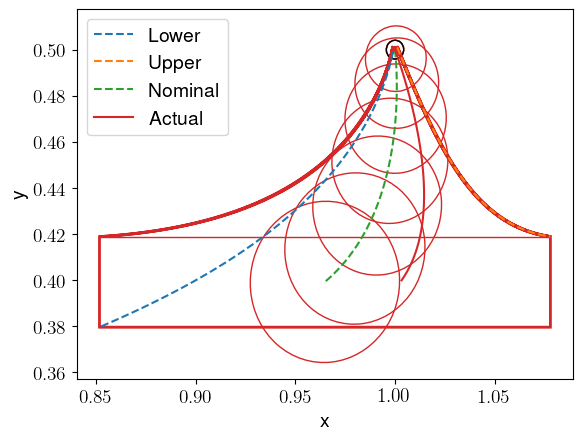

In [85]:
import shapely.ops as so

# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,0], xx[:,1], label='Lower', linestyle="dashed")
plt.plot(xx[:,5], xx[:,6], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,0], xxnom[:,1], label='Nominal', linestyle="dashed")
plt.plot(xa[:,0], xa[:,1], label='Actual')
start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# ellipsoidal tube from algorithm
Ellipsoid(P, xxnom[0, :]).plot_projection(ax, color='tab:gray')
tt = jnp.arange(0, T, dt)
for (i, t) in enumerate(tt[::100]):
    ei = Ellipsoid(P/(np.exp(c*t) + (l/(-1*c))*(1 - np.exp(c*t))*gmax), xxnom[100*i, :])
    ei.plot_projection(ax, color='tab:red') 
    print(ei.V(xa[100*i,:]))
ef = Ellipsoid(P/(np.exp(c*(T-dt)) + (l/(-1*c))*(1 - np.exp(c*(T-dt)))*gmax), xxnom[-1, :])
ef.plot_projection(ax, color='tab:red') 
print(ef.V(xa[-1,:]))

Ellipsoid(orig_P, xxnom[0, :]).plot_projection(ax, color='black')

# TODO: Plot intersection bt/ ellipsoids and rectangles
irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], ec='tab:red')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


